In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.drop("customerID", axis=1, inplace=True)

In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [4]:
df.fillna(df["TotalCharges"].median(), inplace=True)

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

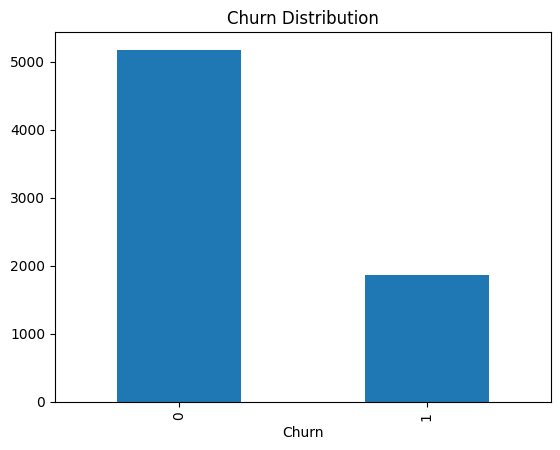

In [6]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.show()

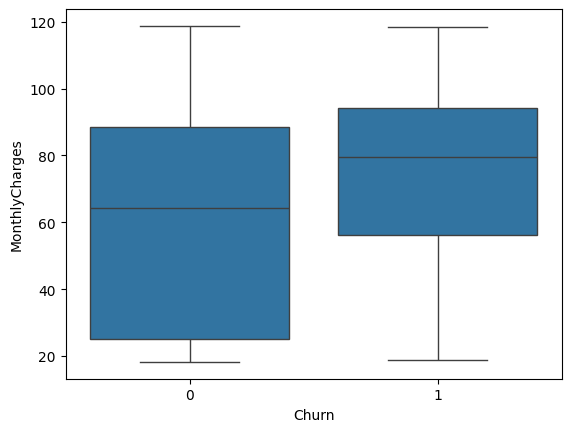

In [7]:
import seaborn as sns

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

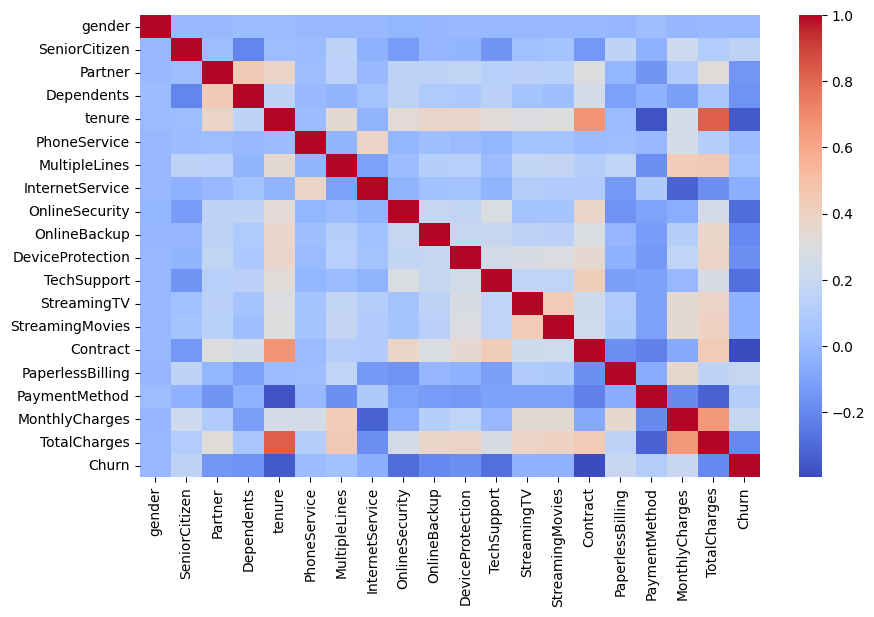

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [11]:
y_pred = model.predict(X_test)

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.7920511000709723
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.65      0.47      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [13]:
print(confusion_matrix(y_test, y_pred))

[[942  94]
 [199 174]]


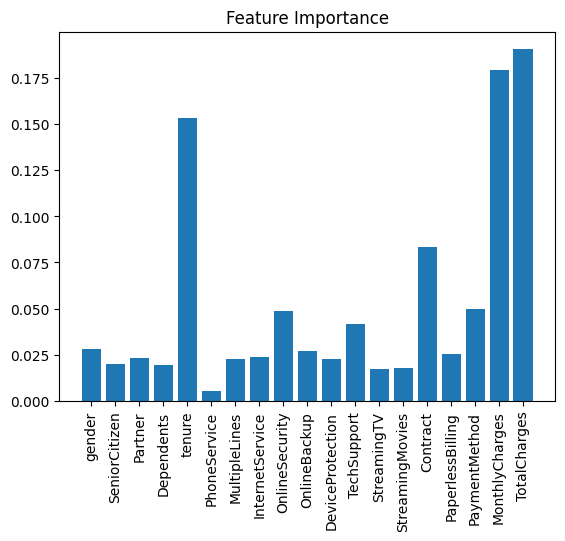

In [14]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.bar(X.columns, importances)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.show()

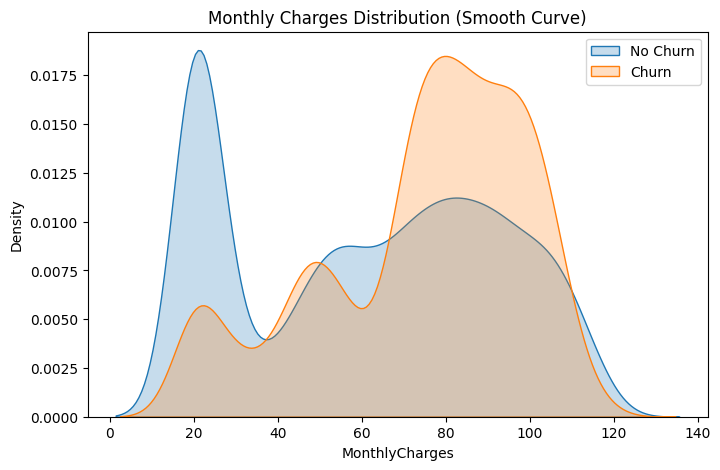

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.kdeplot(df[df["Churn"]==0]["MonthlyCharges"], label="No Churn", fill=True)
sns.kdeplot(df[df["Churn"]==1]["MonthlyCharges"], label="Churn", fill=True)

plt.title("Monthly Charges Distribution (Smooth Curve)")
plt.legend()
plt.show()

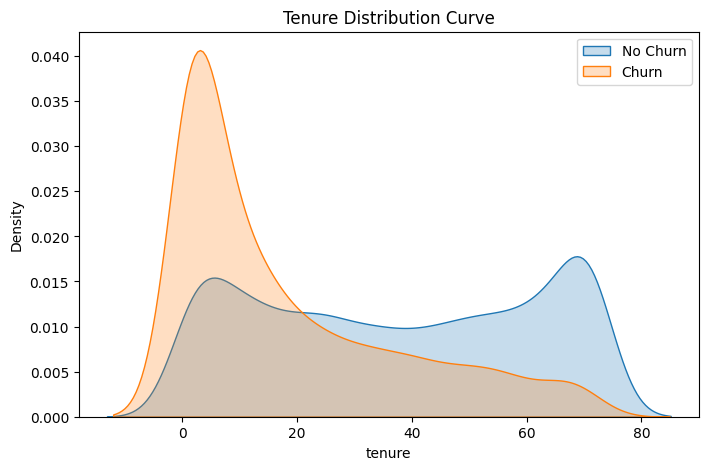

In [16]:
plt.figure(figsize=(8,5))

sns.kdeplot(df[df["Churn"]==0]["tenure"], label="No Churn", fill=True)
sns.kdeplot(df[df["Churn"]==1]["tenure"], label="Churn", fill=True)

plt.title("Tenure Distribution Curve")
plt.legend()
plt.show()

/tmp/ipykernel_822/1047560272.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="coolwarm")


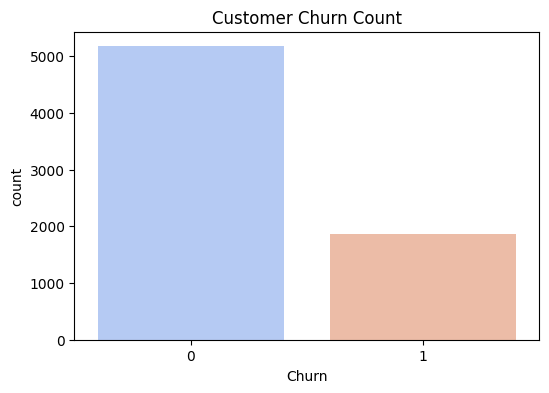

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df, palette="coolwarm")

plt.title("Customer Churn Count")
plt.show()

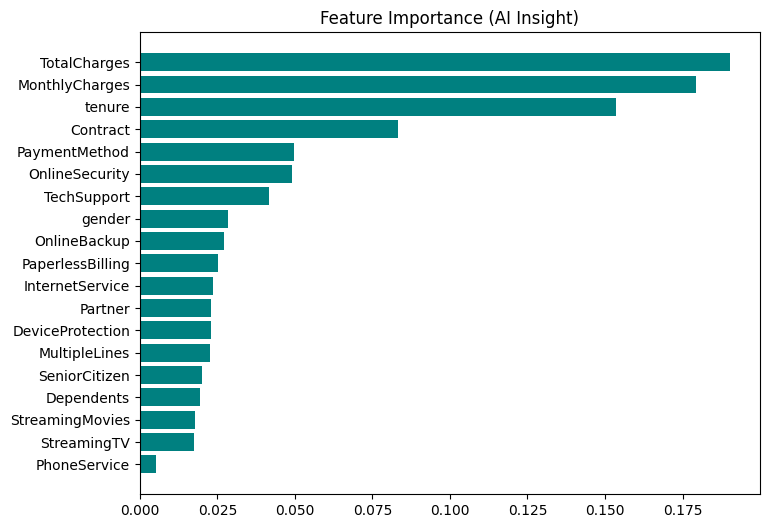

In [18]:
import numpy as np

importances = model.feature_importances_
features = X.columns

sorted_idx = np.argsort(importances)

plt.figure(figsize=(8,6))

plt.barh(features[sorted_idx], importances[sorted_idx], color="teal")

plt.title("Feature Importance (AI Insight)")
plt.show()

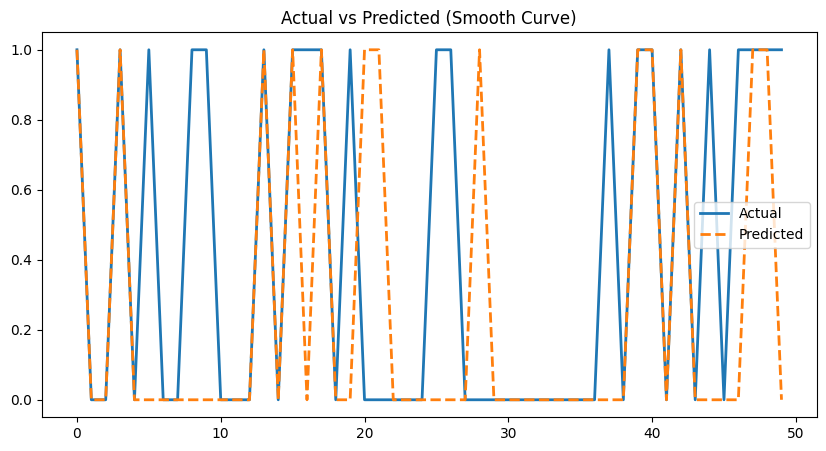

In [20]:
import numpy as np

x = np.arange(50)

plt.figure(figsize=(10,5))

plt.plot(x, y_test[:50], label="Actual", linewidth=2)
plt.plot(x, y_pred[:50], label="Predicted", linestyle="dashed", linewidth=2)

plt.title("Actual vs Predicted (Smooth Curve)")
plt.legend()
plt.show()

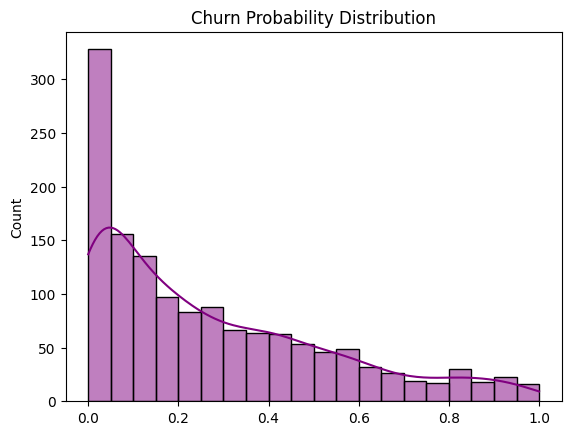

In [21]:
y_prob = model.predict_proba(X_test)[:,1]

sns.histplot(y_prob, bins=20, kde=True, color="purple")

plt.title("Churn Probability Distribution")
plt.show()

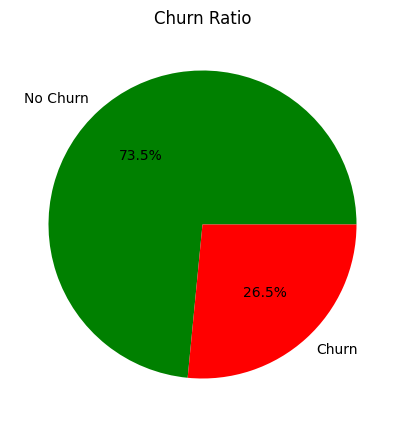

In [22]:
labels = ["No Churn", "Churn"]
sizes = df["Churn"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=["green","red"])

plt.title("Churn Ratio")
plt.show()